# Initial EDA


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
sns.set_style("whitegrid")
pd.set_option("display.max_columns",None)

In [3]:
BASE_DIR = Path().resolve().parent
DATA_PATH = BASE_DIR / "data" / "raw" / "cars.csv"

In [4]:
df = pd.read_csv(DATA_PATH)

### General Information

In [5]:
print(f'Dataset shape: \n{df.shape}')
print("\n----------------------------")
print(f'\nData types:\n {df.dtypes}')
print("\n----------------------------")
print(f'\nNull rows: \n{df.isnull().sum()}')

Dataset shape: 
(4340, 8)

----------------------------

Data types:
 name             object
year              int64
selling_price     int64
km_driven         int64
fuel             object
seller_type      object
transmission     object
owner            object
dtype: object

----------------------------

Null rows: 
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


### Estadistica descriptiva

In [6]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


### Selling_price distribution

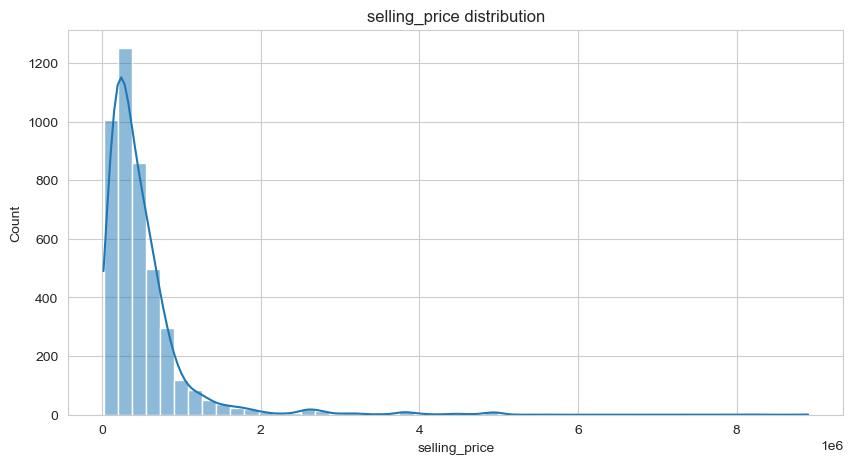

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df["selling_price"],bins=50,kde=True)
plt.title("selling_price distribution")
plt.show()

*La variable selling_price está fuertemente sesgada a la derecha.
La mayoría de vehículos tienen precios bajos/medios y existen pocos valores extremadamente altos.
Será recomendable probar transformación logarítmica del target.*


### BOXPLOT precio (Outliers)

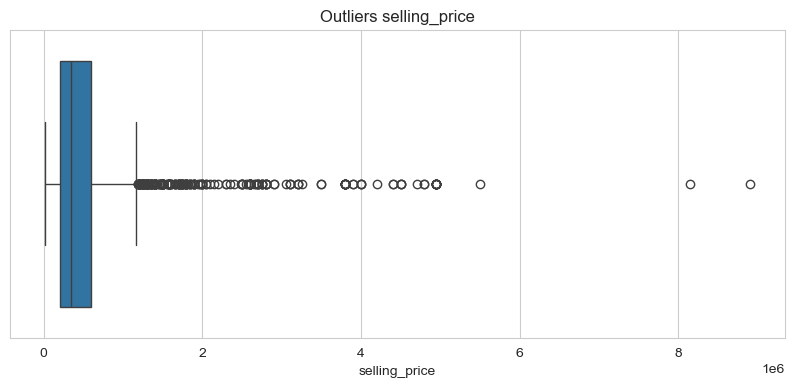

In [9]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['selling_price'])
plt.title("Outliers selling_price")
plt.show()

*selling_price contiene una gran cantidad de valores extremos altos.
La variable está muy sesgada y será recomendable evaluar transformación logarítmica o tratamiento robusto de outliers.*

### Price VS Kilometers

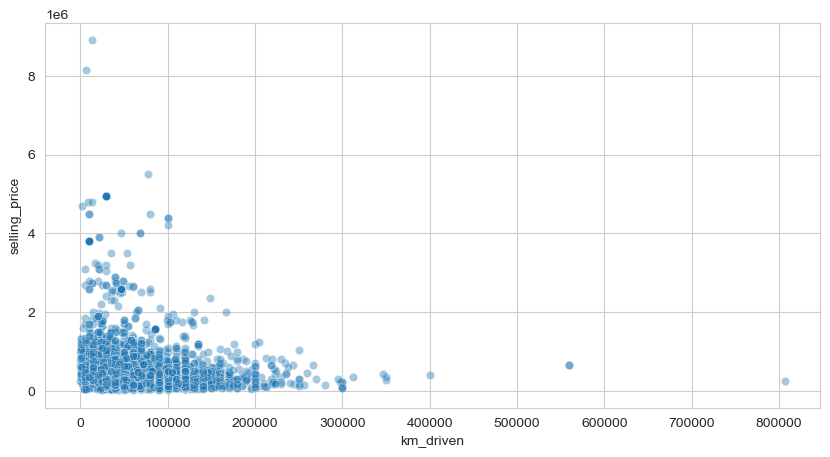

In [10]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    data = df,
    x="km_driven",
    y="selling_price",
    alpha=0.4
    )
plt.title=("km vs price"),
plt.show()

*Existe relación inversa entre kilometraje y precio, aunque con alta dispersión.
km_driven será una variable predictora relevante, pero necesita combinarse con otras variables para capturar el valor real del vehículo.*


### Year VS Price

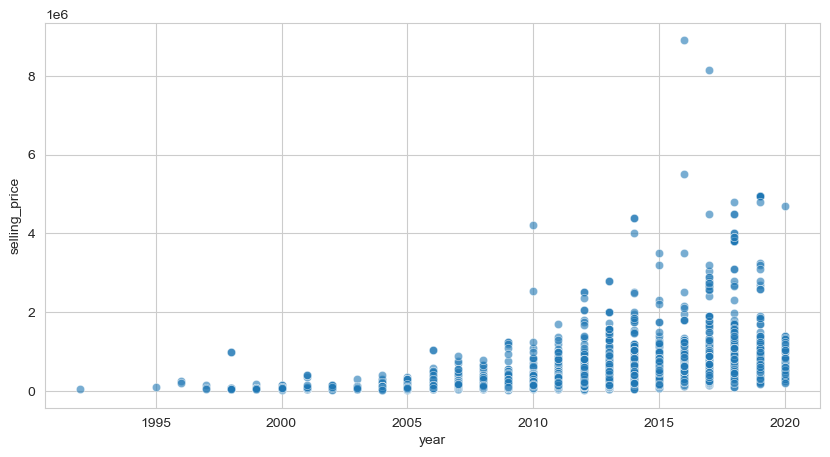

In [11]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    data=df,
    x="year",
    y="selling_price",
    alpha=0.6
)
plt.title=("Year Vs Price")
plt.show()

*Existe una relación positiva clara entre año y precio.
Los vehículos más recientes tienden a tener precios mayores.
La variable year (o una transformación como car_age) será predictora clave.*

### Fuel Counts

In [12]:
df["fuel"].value_counts()

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64

*fuel es una variable categórica relevante.
Diesel y Petrol dominan el dataset.
Las categorías minoritarias deben agruparse para evitar sparsity y ruido.*

### Most common brands

In [13]:
df["brand"] = df["name"].str.strip().str.split().str[0]
df["brand"].value_counts().head(15)

brand
Maruti        1280
Hyundai        821
Mahindra       365
Tata           361
Honda          252
Ford           238
Toyota         206
Chevrolet      188
Renault        146
Volkswagen     107
Skoda           68
Nissan          64
Audi            60
BMW             39
Fiat            37
Name: count, dtype: int64


*brand será una de las variables categóricas más relevantes del proyecto.
Captura posicionamiento de mercado, valor percibido y segmento del vehículo.*

### Average price per brand

In [14]:
df.groupby("brand")["selling_price"].mean().sort_values(ascending=False).head(15)

brand
Land             3.609800e+06
BMW              2.945385e+06
Mercedes-Benz    2.776657e+06
Volvo            2.556250e+06
Jaguar           2.069166e+06
Audi             1.931633e+06
MG               1.842500e+06
Jeep             1.530000e+06
Isuzu            1.500000e+06
Kia              1.300000e+06
Toyota           9.243592e+05
Mitsubishi       8.400000e+05
Mahindra         5.877095e+05
Ford             5.712731e+05
Honda            5.381468e+05
Name: selling_price, dtype: float64

*brand muestra diferencias estructurales claras en precio medio.
Será una de las variables categóricas más influyentes del modelo.*

In [15]:
df["transmission"].value_counts()

transmission
Manual       3892
Automatic     448
Name: count, dtype: int64

*transmission es una variable categórica binaria útil y probablemente predictiva.
Aunque está desbalanceada, dispone de suficientes ejemplos para aportar valor al modelo.*

In [16]:
df["owner"].value_counts()

owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64

*owner es una variable ordinal con fuerte sentido de negocio.
Debe transformarse respetando su orden natural, ya que más propietarios suele asociarse con menor valor del vehículo.*

In [17]:
df["seller_type"].value_counts()

seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64

*seller_type es una variable categórica relevante que captura contexto comercial y confianza del canal de venta.*

# Feature Engineering & Data Preprocessing

In [18]:
#inital data security process
df_model = df.copy()
df_model.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda


---

### Numerical variables

In [19]:
#We converted the variable 'year' into an integer called 'car_age', a variable much easier for the system to understand.
current_year = df_model["year"].max()
df_model['car_age'] = current_year - df_model['year']
df_model.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,car_age
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti,13
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti,13
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai,8
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun,3
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda,6


---

In [20]:
#We created the "km_per_year" column. This is far superior to only looking at total kilometers, since a car with 120.000 km over 12 years is very different from one that reaches 120.000 km in just 2 years.
#The latter strongly suggest intensive use, so the model can take adventage of this new information.

df_model["km_per_year"] = (df_model["km_driven"] / (df_model["car_age"] + 1)).astype(int)
df_model.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,car_age,km_per_year
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti,13,5000
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti,13,3571
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai,8,11111
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun,3,11500
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda,6,20142


---

### Categorical Variables

In [21]:
#Gouping fuel types
df_model["fuel"].value_counts()

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64

In [22]:
df_model["fuel"] = df_model["fuel"].replace({
    "CNG":"Other",
    "LPG":"Other",
    "Electric":"Other"
})

In [23]:
df_model["fuel"].value_counts()

fuel
Diesel    2153
Petrol    2123
Other       64
Name: count, dtype: int64

---

In [24]:
# # The variable "owner" has high value, since it has a natural order. The more previous owners a vehicle had, the lower its value. Therefore, we will use Ordinal Econding.
# df_model["owner"].value_counts()

In [25]:
owner_mapping = {

    "Test Drive Car" : 0,
    "First Owner" : 1,
    "Second Owner" : 2,
    "Third Owner" : 3,
    "Fourth & Above Owner" : 4
}

In [26]:
df_model["owner"] = df_model["owner"].map(owner_mapping).astype("Int64")

In [27]:
df_model["owner"].value_counts().sort_index()

owner
0      17
1    2832
2    1106
3     304
4      81
Name: count, dtype: Int64

---

In [28]:
#We can observe a problem. To resolve it, we change "Land" to "Land Rover"
df_model["brand"].value_counts().head(20)

brand
Maruti           1280
Hyundai           821
Mahindra          365
Tata              361
Honda             252
Ford              238
Toyota            206
Chevrolet         188
Renault           146
Volkswagen        107
Skoda              68
Nissan             64
Audi               60
BMW                39
Fiat               37
Datsun             37
Mercedes-Benz      35
Jaguar              6
Mitsubishi          6
Land                5
Name: count, dtype: int64

In [29]:
df_model["brand"] = df_model["brand"].replace({
    "Land":"Land Rover"
})

In [30]:
#We are going to grout the brands with few examples into "Other". This action improves the quality of our data.
#Variables with very few examples do not provide much Learning value for the model and may introduce noise.

brand_counts = df_model["brand"].value_counts()
rare_brands = brand_counts[brand_counts < 10].index
df_model["brand"] = df_model["brand"].replace(rare_brands,"Other")


In [31]:
df_model["brand"].value_counts().head(20)

brand
Maruti           1280
Hyundai           821
Mahindra          365
Tata              361
Honda             252
Ford              238
Toyota            206
Chevrolet         188
Renault           146
Volkswagen        107
Skoda              68
Nissan             64
Audi               60
BMW                39
Datsun             37
Fiat               37
Other              36
Mercedes-Benz      35
Name: count, dtype: int64

# Modeling Phase

The correct order in modeling phase is:

- Define X and y
- Detect numerical/categorical columns
- Split into train/test
- Build the pipeline with those lists
- Fit on the training set
- Evaluate on the test set

In [32]:
df_model.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'brand', 'car_age', 'km_per_year'],
      dtype='object')

In [33]:
#We keep the columns that we want as features, as well as the target 'y'. We remove everything that is not worth keeping, such as the full name column or the year column
X = df_model.drop(columns=[
    "selling_price",
    "name",
    "year"
    ])

y = df_model["selling_price"]

In [34]:
X.head(2)

,km_driven,fuel,seller_type,transmission,owner,brand,car_age,km_per_year
0,70000,Petrol,Individual,Manual,1,Maruti,13,5000
1,50000,Petrol,Individual,Manual,1,Maruti,13,3571


---

In [35]:
#We are going to separate the features into two different classes: Numerical and Categorical.

numerical_features = X.select_dtypes(include=["Int64","int64","float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


---

In [36]:
#Making the data split.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=7
)

In [37]:
#We are going to verify the data split.
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3472, 8), (868, 8), (3472,), (868,))

In [38]:
#I'm going to build the baseline model: Linear Regression.

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num","passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"),categorical_features)
    ]
)

In [40]:
model = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("regressor",LinearRegression())
])

In [41]:
model.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [42]:
preds = model.predict(X_test)

In [43]:
#Observing how well it has performed

from sklearn.metrics import mean_absolute_error, mean_squared_error ,r2_score
import numpy as np

mae = mean_absolute_error(y_test,preds)
rmse = np.sqrt(mean_squared_error(y_test,preds))
r2 = r2_score(y_test,preds)

print("MAE:", round(mae,2))
print("RMSE:",round(rmse,2))
print("R^2:",round(r2,2))

MAE: 209395.38
RMSE: 371532.5
R^2: 0.51


---

### Baseline Metrics:

- MAE: 209395.4
- RMSE: 371532.5
- R^2: 0.51


*The model makes an average error of 209,395.38 monetary units (MAE). When the model makes large mistakes, those errors weigh more heavily, like 371,531.50 (RMSE). It xplains approximately 51% of the price behavior(R^2)*

In [44]:
#Second model: Random Forest Regressor. I'm going to use the same preprocesor in the new pipeline.

from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=7,
        n_jobs=-1
    ))
])

In [45]:
rf_model.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [46]:
rf_model_preds = rf_model.predict(X_test)

In [47]:
#Metrics:

rf_mae = mean_absolute_error(y_test,rf_model_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test,rf_model_preds))
rf_r2 = r2_score(y_test,rf_model_preds)

print("RF MAE:" , round(rf_mae,2))
print("RF RMSE:" , round(rf_rmse,2))
print("RF R2:", round(rf_r2, 2))

RF MAE: 113032.43
RF RMSE: 201630.34
RF R2: 0.86


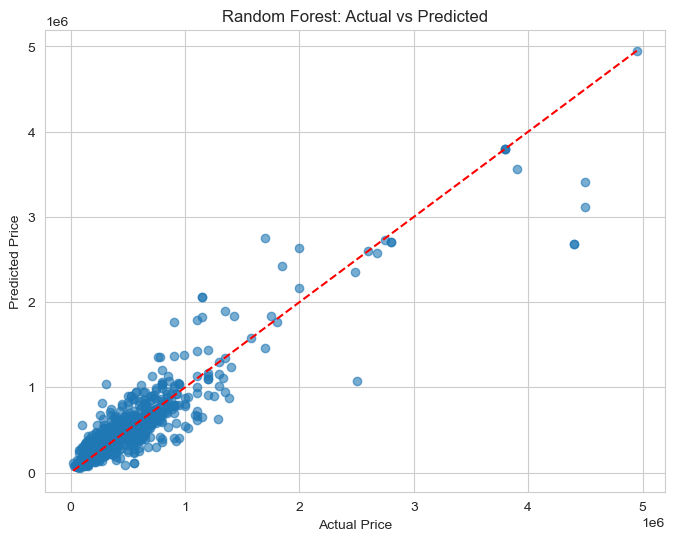

In [48]:
#Strong improvement. Comparative graphs.
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, rf_model_preds, alpha=0.6)

ax.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")
ax.set_title("Random Forest: Actual vs Predicted")

plt.show()

*The scatter plot shows a strong positive relationship between actual and predicted prices, indicating that the Random Forest model performs well overall. Most points are concentrated close to the diagonal reference line, which represents perfect predictions. This suggests that the model captures price patterns accurately.*

---

In [49]:
 #Testing XGBoost. Data preparation for early stopping. Until now, the X_train and X_test split was valid. For early stopping, a subdivision into 3 sets is necessary.

from xgboost import XGBRegressor

X_train_main, X_valid, y_train_main, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=7
)

In [50]:
#Adjustments to the preprocessor to include the validation set
preprocessor.fit(X_train_main)

X_train_main_processed = preprocessor.transform(X_train_main)
X_valid_processed = preprocessor.transform(X_valid)
X_test_processed = preprocessor.transform(X_test)

In [51]:
xgb_model = XGBRegressor(
    n_estimators=1000,#ajá!;)
    learning_rate=0.05,
    max_depth=6,
    random_state=7,
    n_jobs=-1,
    early_stopping_rounds=50#yeah!
)

In [52]:
xgb_model.fit(
    X_train_main_processed,
    y_train_main,
    eval_set=[(X_valid_processed,y_valid)],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,None


In [53]:
xgb_preds = xgb_model.predict(X_test_processed)

xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

print(f"XGB MAE: {xgb_mae:.2f}")
print(f"XGB RMSE: {xgb_rmse:.2f}")
print(f"XGB R2: {xgb_r2:.2f}")
print(f"Best iteration: {xgb_model.best_iteration}")

XGB MAE: 108133.11
XGB RMSE: 178180.01
XGB R2: 0.89
Best iteration: 365


---


In [54]:
#Testing CatBoost

from catboost import CatBoostRegressor

In [55]:
cat_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=7,
    verbose=False
)

In [56]:
#Train with early-stopping. Using data without One-Hot encode. (x_train_main,x_valid,x_test)
cat_model.fit(
    X_train_main,
    y_train_main,
    cat_features=categorical_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
    early_stopping_rounds=50
)

CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=2000, learning_rate=0.05, loss_function='RMSE', random_seed=7, verbose=False)

In [57]:
cat_preds = cat_model.predict(X_test)

In [58]:
cat_mae = mean_absolute_error(y_test, cat_preds)
cat_rmse = np.sqrt(mean_squared_error(y_test, cat_preds))
cat_r2 = r2_score(y_test, cat_preds)

print(f"CatBoost MAE: {cat_mae:.2f}")
print(f"CatBoost RMSE: {cat_rmse:.2f}")
print(f"CatBoost R2: {cat_r2:.2f}")
print(f"Best iteration: {cat_model.get_best_iteration()}")

CatBoost MAE: 122193.21
CatBoost RMSE: 222494.46
CatBoost R2: 0.82
Best iteration: 428


---

# Model Performance Comparison Graph

![Model Comparison](../media/model-performance-comparison.png)

*After comparing multiple regression models, XGBoost with Early Stopping achieved the best overall performance, obtaining the lowest prediction errors and the highest R² score.*
*This confirms that gradient boosting methods are highly effective for structured tabular datasets such as used car pricing problems.*

*The project also demonstrated the importance of feature engineering, especially variables such as car_age, km_per_year, and brand extraction.*

---

# Final Model Serialization

In [59]:
import joblib

joblib.dump(xgb_model, "../models/xgb_used_car_model.pk1")

['../models/xgb_used_car_model.pk1']